# 02 — UN Voting Alignment: DiD Analysis

Estimates the causal effect of US foreign aid cuts on countries' UN voting alignment with China and the US using a Difference-in-Differences design.

**Treatment:** Top 25% of countries by 2024 aid/GDP ratio (threshold ≈ 0.53% of GDP; 48 countries treated)  
**Pre/Post:** 2000–2024 (pre) vs. 2025 (post-USAID cuts)  
**Outcomes:** Annual mean UN voting alignment with the US and China (restricted to contested US–China resolutions)

**Sections:** Average alignments → trends plot → aid-over-time plot → DiD regression → parallel trends test

In [ ]:
import pandas as pd
import numpy as np
import re
import gdown  # needed to get data from Google Drive

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker  # used in section 5 (parallel trends plot)

import statsmodels.formula.api as smf              # used in section 4 (DiD OLS)
from statsmodels.iolib.summary2 import summary_col  # used in section 4 (regression table)
from statsmodels.iolib.table import SimpleTable     # used in section 5 (LaTeX export)

from scipy import stats  # used in section 5 (linear trend test)

## print multiple things from same cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

gdown.download(id="1Sw8kegqF-n9TIbTjc9Nq-n0wO4WtoGor", output="df_clean.csv", quiet=False)
df = pd.read_csv("df_clean.csv")

print(df.shape)
print(df.head())

# 1. Average Alignments

#### 1.1 Alignment by country and year

In [3]:
alignment = df.groupby(['ms_code', 'ms_name', 'year']).agg(
    us_alignment=('align_us', 'mean'),
    cn_alignment=('align_china', 'mean')
).reset_index()

alignment

,ms_code,ms_name,year,us_alignment,cn_alignment
0,AFG,AFGHANISTAN,2000,0.206897,0.948276
1,AFG,AFGHANISTAN,2001,0.138889,0.930556
2,AFG,AFGHANISTAN,2002,0.128571,0.942857
3,AFG,AFGHANISTAN,2003,0.115385,0.951923
4,AFG,AFGHANISTAN,2004,0.100000,0.963636
...,...,...,...,...,...
4910,ZWE,ZIMBABWE,2021,0.123188,0.921429
4911,ZWE,ZIMBABWE,2022,0.189394,0.915385
4912,ZWE,ZIMBABWE,2023,0.198630,0.868056
4913,ZWE,ZIMBABWE,2024,0.182432,0.905405


#### 1.2 Alignment by country

In [81]:
alignment_just_country = df.groupby('ms_name').agg(
    us_alignment=('align_us', 'mean'),
    cn_alignment=('align_china', 'mean')
).reset_index()

alignment_just_country

,ms_name,us_alignment,cn_alignment
0,AFGHANISTAN,0.149315,0.911196
1,ALBANIA,0.470160,0.623959
2,ALGERIA,0.121452,0.937999
3,ANDORRA,0.412658,0.670674
4,ANGOLA,0.148206,0.909974
...,...,...,...
187,VENEZUELA,0.113018,0.941061
188,VIET NAM,0.119534,0.927613
189,YEMEN,0.141500,0.914430
190,ZAMBIA,0.146791,0.910250


#### 1.3 Alignment by year

In [82]:
alignment_just_year = df.groupby('year').agg(
    us_alignment=('align_us', 'mean'),
    cn_alignment=('align_china', 'mean')
).reset_index()

alignment_just_year

,year,us_alignment,cn_alignment
0,2000,0.316405,0.832843
1,2001,0.279628,0.830074
2,2002,0.233469,0.849478
3,2003,0.234736,0.835926
4,2004,0.228847,0.847041
5,2005,0.222575,0.836090
6,2006,0.232325,0.871387
7,2007,0.194919,0.850440
8,2008,0.195358,0.847782
9,2009,0.277204,0.820804


# 2. Plot of alignment scores across time

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Global UN Voting Alignment with US vs China (2000–2025)')

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Alignment Score (0–1)')

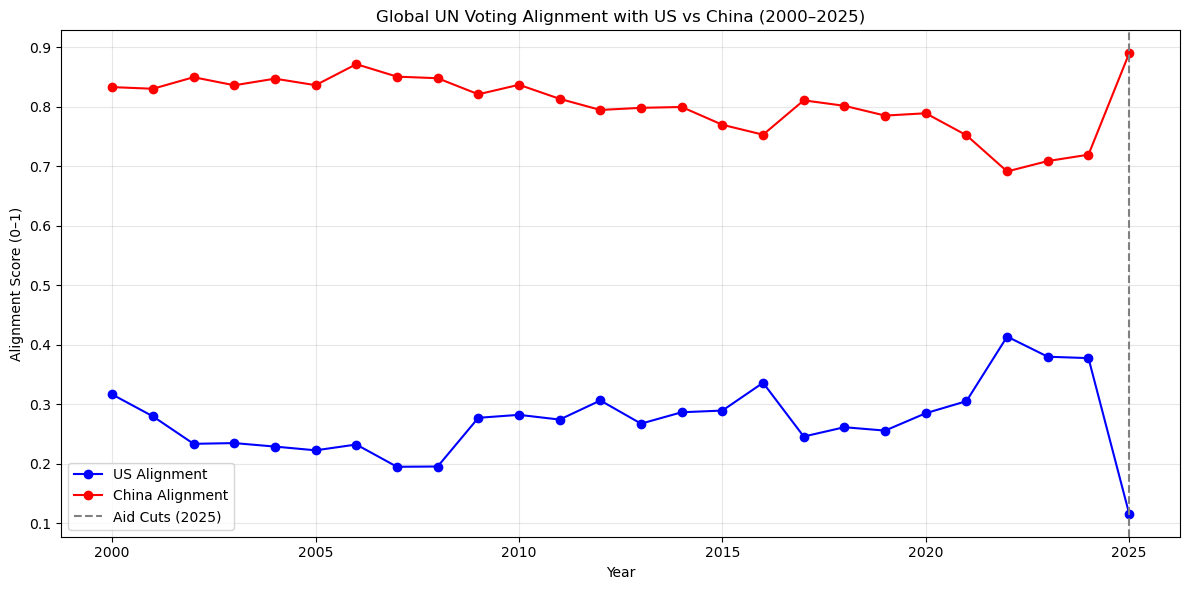

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(alignment_just_year.year, alignment_just_year.us_alignment, 
         marker='o', label='US Alignment', color='blue')
plt.plot(alignment_just_year.year, alignment_just_year.cn_alignment, 
         marker='o', label='China Alignment', color='red')

plt.axvline(x=2025, color='gray', linestyle='--', label='Aid Cuts (2025)')

plt.title('Global UN Voting Alignment with US vs China (2000–2025)')
plt.xlabel('Year')
plt.ylabel('Alignment Score (0–1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../output/global_alignment_us_vs_china.png', dpi=150, bbox_inches='tight')
plt.tight_layout()

# 3. Graph showing cuts in US foreign assistance.

Coding a graph which just shows how Foreign assistance has changed over the years.
IMPT: each row symbolizes a vote. so the aid and GDP are repeated on each row. Also important to note that i am using the original aid dataset, because when it is combined w the UN votes data is lost (e.g. only kept the ones where US and China were misaligned)

Downloading...
From: https://drive.google.com/uc?id=1olxIzOBAbjpbLfrlvFkPqAfDF2UFe-UI
To: /Users/charlesphillips/Documents/GitHub/qss20-final-project/code/us_foreign_aid_country.csv
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2.41M/2.41M [00:00<00:00, 9.82MB/s]


'us_foreign_aid_country.csv'

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Total US Foreign Assistance (Constant USD Billions)')

Text(0.5, 1.0, 'US Foreign Assistance Over Time')

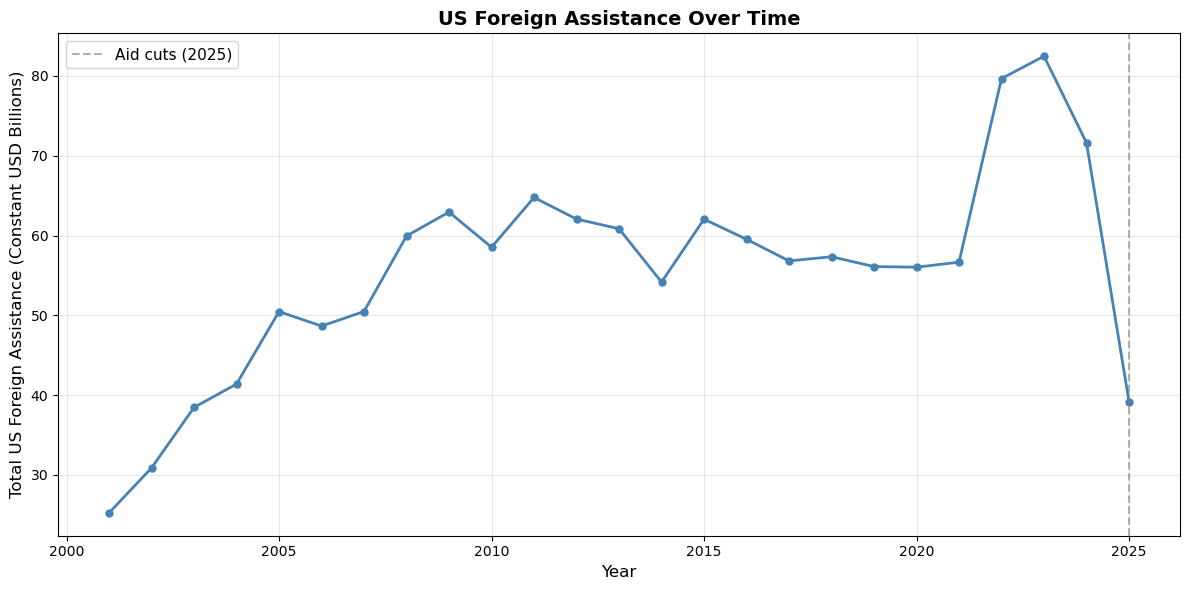

In [84]:
# Reload aid_clean directly so we're not limited by the voting data merge
gdown.download(id="1olxIzOBAbjpbLfrlvFkPqAfDF2UFe-UI", output="us_foreign_aid_country.csv", quiet=False)
aid = pd.read_csv("us_foreign_aid_country.csv")
aid_clean = aid[aid['Transaction Type Name'] == 'Disbursements'].copy()

# Aggregate by year
aid_by_year = aid_clean.groupby('Fiscal Year')['constant_amount'].sum().sort_index().reset_index()
aid_by_year['Fiscal Year'] = aid_by_year['Fiscal Year'].astype(int)
aid_by_year['aid_bn'] = aid_by_year['constant_amount'] / 1e9

# Drop 2026 - incomplete year
aid_by_year = aid_by_year[aid_by_year['Fiscal Year'] <= 2025]

plt.figure(figsize=(12, 6))
plt.plot(aid_by_year['Fiscal Year'], aid_by_year['aid_bn'],
         marker='o', markersize=5, color='steelblue', linewidth=2)
plt.axvline(x=2025, color='gray', linestyle='--', alpha=0.6, label='Aid cuts (2025)')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total US Foreign Assistance (Constant USD Billions)', fontsize=12)
plt.title('US Foreign Assistance Over Time', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/us_foreign_assistance_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Diff-in-diff

I first need to work out what the threshold is for treatment

In [11]:
# Get one row per country with their aid_gdp_ratio in 2024 to decipher who was hardest hit and thus what the threshold is for treatment
aid_reliance = (
    df[df['year'] == 2024]
    .groupby('ms_name')['aid_gdp_ratio']
    .mean()
    .fillna(0)
    .reset_index()
    .sort_values('aid_gdp_ratio', ascending=False)
)

print(aid_reliance.describe())
print(aid_reliance['aid_gdp_ratio'].quantile([0.5, 0.75, 0.90]))
aid_reliance.head(20)

       aid_gdp_ratio
count     189.000000
mean        1.922476
std        12.512254
min         0.000000
25%         0.002977
50%         0.082417
75%         0.533071
max       150.204147
0.50    0.082417
0.75    0.533071
0.90    1.738423
Name: aid_gdp_ratio, dtype: float64


,ms_name,aid_gdp_ratio
105,MARSHALL ISLANDS,150.204147
109,MICRONESIA (FEDERATED STATES OF),77.143602
128,PALAU,36.239114
157,SOMALIA,8.043437
159,SOUTH SUDAN,7.013478
178,UKRAINE,5.326919
93,LESOTHO,4.938364
31,CENTRAL AFRICAN REPUBLIC,4.281262
94,LIBERIA,3.672568
100,MALAWI,3.558498


using the 75th percentile as threshold as that is ~0.5% GDP which is relatively high.

In [12]:
# Define treatment variable
threshold = aid_reliance['aid_gdp_ratio'].quantile(0.75)
print(f"Threshold: {threshold:.3f}% of GDP")

high_aid_countries = aid_reliance[aid_reliance['aid_gdp_ratio'] >= threshold]['ms_name']
print(f"Treated countries: {len(high_aid_countries)}")
print(f"Control countries: {len(aid_reliance) - len(high_aid_countries)}")

# Merge treatment indicator onto main df
df['treated'] = df['ms_name'].isin(high_aid_countries).astype(int)
df['post'] = (df['year'] >= 2025).astype(int)

# Verify
print(df.groupby('treated')['ms_name'].nunique())
print(df['treated'].value_counts())

Threshold: 0.533% of GDP
Treated countries: 48
Control countries: 141
treated
0    144
1     48
Name: ms_name, dtype: int64
treated
0    286925
1     86707
Name: count, dtype: int64


In [13]:

# Post and treated already defined, now create the interaction term
df['did'] = df['treated'] * df['post']

# Aggregate to country-year level (one obs per country-year for the regression)
did_df = df.groupby(['ms_name', 'ms_code', 'year', 'treated', 'post', 'did']).agg(
    align_china=('align_china', 'mean'),
    align_us=('align_us', 'mean'),
    aid_disbursement=('aid_disbursement', 'mean'),
    gdp=('gdp', 'mean'),
    aid_gdp_ratio=('aid_gdp_ratio', 'mean')
).reset_index()

print(did_df.shape)
print(did_df.head())

(4915, 11)
       ms_name ms_code  year  treated  post  did  align_china  align_us  \
0  AFGHANISTAN     AFG  2000        0     0    0     0.948276  0.206897   
1  AFGHANISTAN     AFG  2001        0     0    0     0.930556  0.138889   
2  AFGHANISTAN     AFG  2002        0     0    0     0.942857  0.128571   
3  AFGHANISTAN     AFG  2003        0     0    0     0.951923  0.115385   
4  AFGHANISTAN     AFG  2004        0     0    0     0.963636  0.100000   

   aid_disbursement           gdp  aid_gdp_ratio  
0      0.000000e+00  3.521418e+09       0.000000  
1      6.859911e+07  2.813572e+09       2.438150  
2      6.627629e+08  3.825701e+09      17.323958  
3      1.152245e+09  4.520947e+09      25.486810  
4      1.966389e+09  5.224897e+09      37.634975  


In [8]:
## DiD

import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

model_china = smf.ols(
    'align_china ~ treated + post + did',
    data=did_df
).fit(cov_type='HC3')

model_us = smf.ols(
    'align_us ~ treated + post + did',
    data=did_df
).fit(cov_type='HC3')

for label, model in [('China Alignment', model_china), ('US Alignment', model_us)]:
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  treated: {model.params['treated']:+.4f}  (p={model.pvalues['treated']:.3f})")
    print(f"  post:    {model.params['post']:+.4f}  (p={model.pvalues['post']:.3f})")
    print(f"  did:     {model.params['did']:+.4f}  (p={model.pvalues['did']:.3f})  ← key")
    print(f"  N={int(model.nobs)}, R²={model.rsquared:.3f}")

table = summary_col(
    [model_china, model_us],
    model_names=['China Alignment', 'US Alignment'],
    stars=True,
    regressor_order=['treated', 'post', 'did'],
    drop_omitted=True,
    info_dict={
        'N':  lambda m: f"{int(m.nobs)}",
        'R²': lambda m: f"{m.rsquared:.3f}",
    }
)

print('\n', table)

with open('../output/did_un_results.tex', 'w') as f:
    f.write(table.as_latex())

print("Saved → ../output/did_un_results.tex")


  China Alignment
  treated: +0.0281  (p=0.000)
  post:    +0.0890  (p=0.000)
  did:     -0.0054  (p=0.780)  ← key
  N=4915, R²=0.017

  US Alignment
  treated: -0.0411  (p=0.000)
  post:    -0.1645  (p=0.000)
  did:     +0.0161  (p=0.453)  ← key
  N=4915, R²=0.040

 
               China Alignment US Alignment
-------------------------------------------
treated        0.0281***       -0.0411***  
               (0.0060)        (0.0064)    
post           0.0890***       -0.1645***  
               (0.0079)        (0.0088)    
did            -0.0054         0.0161      
               (0.0194)        (0.0215)    
R-squared      0.0171          0.0401      
R-squared Adj. 0.0165          0.0395      
N              4915            4915        
R²             0.017           0.040       
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


779

Saved → ../output/did_un_results.tex


# 5. Parallel Trends Assumption

We validate the parallel trends assumption for the DiD above. High-aid and low-aid countries should trend together in China voting alignment throughout 2000–2024, before any divergence in 2025.

1. **Visually** — a two-line chart showing both groups moving in parallel pre-2025
2. **Statistically** — a gap analysis and joint F-test confirming no significant pre-treatment trend

#### 5.1 Alignment by group over time

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Average China Alignment Score (0–1)')

Text(0.5, 1.0, 'UN Voting Alignment with China Over Time\nby US Foreign Aid Reliance')

(0.55, 1.0)

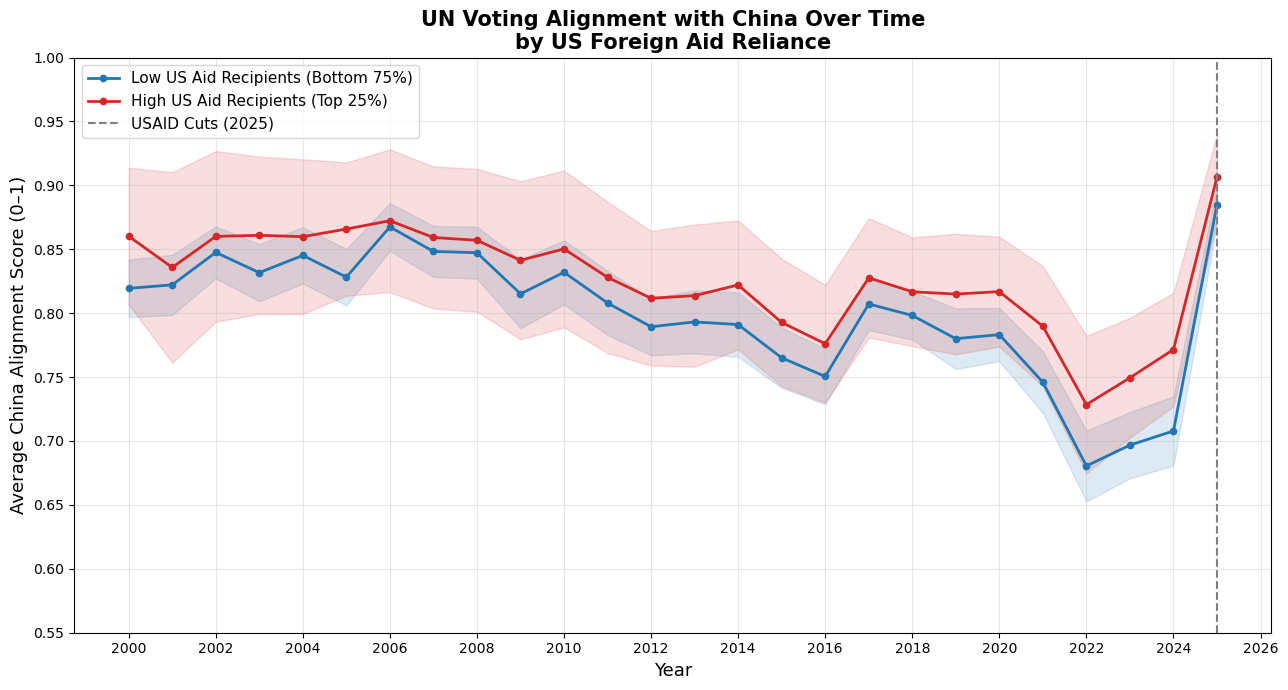

In [102]:
import matplotlib.ticker as mticker

# did_df already has country-year observations with treated column
# compute yearly mean alignment and 95% CI by treatment group
plot_df = (
    did_df.groupby(['year', 'treated'])['align_china']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)
plot_df.columns = ['year', 'treated', 'mean_align', 'se', 'n_countries']
plot_df['ci_low']  = plot_df['mean_align'] - 1.96 * plot_df['se']
plot_df['ci_high'] = plot_df['mean_align'] + 1.96 * plot_df['se']
plot_df['group_label'] = plot_df['treated'].map({
    1: 'High US Aid (Top 25%)',
    0: 'Low US Aid (Bottom 75%)'
})

fig, ax = plt.subplots(figsize=(13, 7))
style = {
    1: {'color': '#d62728', 'label': 'High US Aid Recipients (Top 25%)'},
    0: {'color': '#1f77b4', 'label': 'Low US Aid Recipients (Bottom 75%)'}
}
for grp, grp_data in plot_df.groupby('treated'):
    grp_data = grp_data.sort_values('year')
    c = style[grp]['color']
    ax.plot(grp_data['year'], grp_data['mean_align'],
            marker='o', markersize=4.5, linewidth=2, color=c, label=style[grp]['label'])
    ax.fill_between(grp_data['year'], grp_data['ci_low'], grp_data['ci_high'],
                    alpha=0.15, color=c)

ax.axvline(x=2025, color='gray', linestyle='--', linewidth=1.5, label='USAID Cuts (2025)')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Average China Alignment Score (0–1)', fontsize=13)
ax.set_title('UN Voting Alignment with China Over Time\nby US Foreign Aid Reliance',
             fontsize=15, fontweight='bold')
ax.set_ylim(0.55, 1.0)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/china_alignment_by_aid_group.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.2 Statistical Test

We test whether the treated−control gap was trending over the pre-2025 period. A flat gap (slope ≈ 0) supports parallel trends.

In [15]:
from scipy import stats

# Year-by-year treated vs control mean alignment
yearly = (
    did_df.groupby(['year', 'treated'])['align_china']
    .mean()
    .reset_index()
    .pivot(index='year', columns='treated', values='align_china')
    .rename(columns={0: 'control', 1: 'treated'})
)
yearly['gap'] = yearly['treated'] - yearly['control']
pre = yearly[yearly.index < 2025]

print(f'{"Year":>6}  {"Treated":>8}  {"Control":>8}  {"Gap":>8}')
print('-' * 38)
for yr, row in yearly.iterrows():
    marker = ' ← treatment' if yr == 2025 else ''
    print(f'{yr:>6}  {row["treated"]:>8.4f}  {row["control"]:>8.4f}  {row["gap"]:>8.4f}{marker}')

pre_years = pre.index.values.astype(float)
pre_gaps  = pre['gap'].values

# Linear trend in pre-2025 gap — H₀: slope = 0 (gap not trending over time)
slope, intercept, r, p_trend, se_slope = stats.linregress(pre_years, pre_gaps)

print('\n' + '=' * 60)
print('  Linear trend test for parallel trends')
print('=' * 60)
print(f'   Slope = {slope:.6f}  |  p = {p_trend:.4f}', '  ✓ No trend' if p_trend > 0.05 else '  ✗ Significant trend')
print('=' * 60)

  Year   Treated   Control       Gap
--------------------------------------
  2000    0.8603    0.8191    0.0413
  2001    0.8371    0.8216    0.0155
  2002    0.8614    0.8470    0.0144
  2003    0.8604    0.8317    0.0287
  2004    0.8605    0.8449    0.0156
  2005    0.8656    0.8280    0.0376
  2006    0.8735    0.8671    0.0064
  2007    0.8601    0.8479    0.0122
  2008    0.8580    0.8469    0.0111
  2009    0.8428    0.8145    0.0283
  2010    0.8517    0.8314    0.0203
  2011    0.8283    0.8077    0.0205
  2012    0.8117    0.7892    0.0225
  2013    0.8152    0.7925    0.0227
  2014    0.8236    0.7904    0.0332
  2015    0.7942    0.7644    0.0298
  2016    0.7772    0.7499    0.0273
  2017    0.8287    0.8067    0.0220
  2018    0.8181    0.7976    0.0205
  2019    0.8160    0.7794    0.0366
  2020    0.8178    0.7827    0.0352
  2021    0.7906    0.7454    0.0453
  2022    0.7300    0.6796    0.0504
  2023    0.7505    0.6961    0.0545
  2024    0.7723    0.7071    0.0652

In [17]:
from statsmodels.iolib.table import SimpleTable

headers = ['Statistic', 'Value']
data = [
    ['Slope',                   f'{slope:.6f}'],
    ['Std. Error',              f'{se_slope:.6f}'],
    ['R',                       f'{r:.4f}'],
    ['p-value',                 f'{p_trend:.4f}'],
    ['Significant (p < 0.05)',  'No' if p_trend > 0.05 else 'Yes'],
]

tbl = SimpleTable(data, headers, title='Parallel Trends: Linear Trend Test (UN Voting Alignment)')

with open('../output/un_linear_test.tex', 'w') as f:
    f.write(tbl.as_latex_tabular())
print("Saved → ../output/un_linear_test.tex")

423

Saved → ../output/un_linear_test.tex


Text(0.5, 0, 'Year')

Text(0, 0.5, 'Mean China Alignment Score (0–1)')

Text(0.5, 1.0, 'China Alignment Over Time\nHigh-Aid vs Low-Aid Countries')

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Treated − Control Gap in China Alignment')

Text(0.5, 1.0, 'Treated − Control Alignment Gap Over Time\nFlat pre-2025 line = parallel trends holds')

Text(0.5, 1.01, 'Parallel Trends: High-Aid vs Low-Aid Countries')

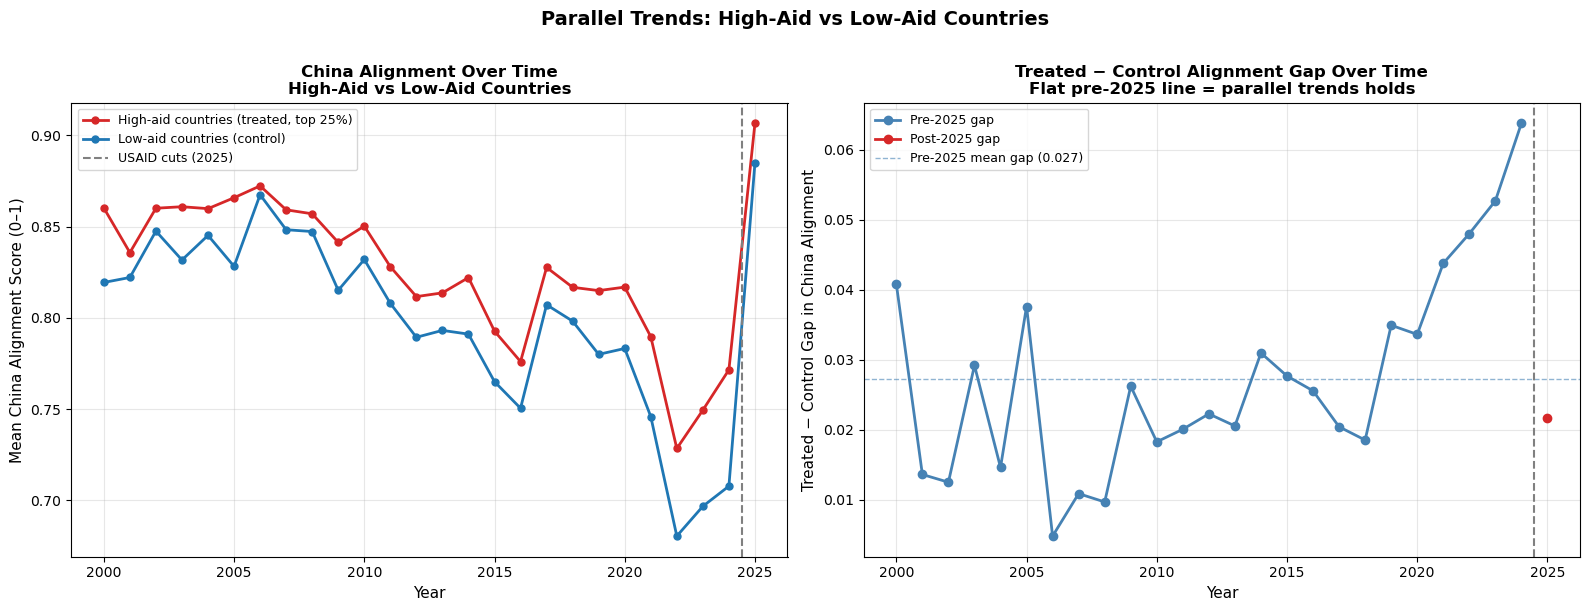

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: raw group trends
ax1 = axes[0]
ax1.plot(yearly.index, yearly['treated'], marker='o', markersize=5,
         color='#d62728', linewidth=2, label='High-aid countries (treated, top 25%)')
ax1.plot(yearly.index, yearly['control'], marker='o', markersize=5,
         color='#1f77b4', linewidth=2, label='Low-aid countries (control)')
ax1.axvline(x=2024.5, color='gray', linestyle='--', linewidth=1.5, label='USAID cuts (2025)')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Mean China Alignment Score (0–1)', fontsize=11)
ax1.set_title('China Alignment Over Time\nHigh-Aid vs Low-Aid Countries',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: treated − control gap
ax2 = axes[1]
pre_gap  = yearly[yearly.index < 2025]
post_gap = yearly[yearly.index >= 2025]
ax2.plot(pre_gap.index,  pre_gap['gap'],  marker='o', color='steelblue', linewidth=2, label='Pre-2025 gap')
ax2.plot(post_gap.index, post_gap['gap'], marker='o', color='#d62728',   linewidth=2, label='Post-2025 gap')
mean_pre_gap = pre_gap['gap'].mean()
ax2.axhline(y=mean_pre_gap, color='steelblue', linestyle='--', linewidth=1,
            alpha=0.6, label=f'Pre-2025 mean gap ({mean_pre_gap:.3f})')
ax2.axvline(x=2024.5, color='gray', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Treated − Control Gap in China Alignment', fontsize=11)
ax2.set_title('Treated − Control Alignment Gap Over Time\nFlat pre-2025 line = parallel trends holds',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle('Parallel Trends: High-Aid vs Low-Aid Countries',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/parallel_trends.png', dpi=150, bbox_inches='tight')
plt.show()